In [92]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

import shap
import matplotlib.pyplot as plt

In [93]:
df = pd.read_csv('loan.csv', low_memory=False)

print(f"Original dataset shape: {df.shape}")

Original dataset shape: (887379, 74)


In [94]:
# ---------------------------------------------------------
# PRO-TIP: Standardize column names to make coding easier
# ---------------------------------------------------------
# This makes all columns lowercase and replaces spaces with underscores
# so you don't get errors from weird formatting in your raw data.
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [95]:
# ==========================================
# STEP 1: Define Your Target Variable
# ==========================================
target_col = 'loan_status' 

if target_col in df.columns:
    # 1. Standardize the text in the status column to lowercase
    df[target_col] = df[target_col].astype(str).str.lower()
    
    # 2. Filter out active loans (handling various LendingClub text formats)
    active_statuses = ['current', 'in grace period', 'issued', 'late (16-30 days)', 'late (31-120 days)']
    df = df[~df[target_col].isin(active_statuses)]

    # 3. Create Binary Label (0 = Good, 1 = Bad)
    # Using a function to catch variations like "Does not meet the credit policy. Status:Charged Off"
    def map_status(status):
        if 'fully paid' in status:
            return 0
        elif 'charged off' in status or 'default' in status:
            return 1
        else:
            return np.nan # Flags anything we missed as missing data

    df[target_col] = df[target_col].apply(map_status)
    
    # Drop rows that didn't match our criteria
    df = df.dropna(subset=[target_col])
    
    print(f"\nShape after filtering target variable: {df.shape}")
    print("Target Variable Distribution (0=Good, 1=Bad):")
    print(df[target_col].value_counts())
else:
    print(f"\nERROR: Could not find '{target_col}' column. Please check your raw data headers.")


Shape after filtering target variable: (256939, 74)
Target Variable Distribution (0=Good, 1=Bad):
loan_status
0    209711
1     47228
Name: count, dtype: int64


In [96]:
# ==========================================
# STEP 2: Eliminate Data Leakage
# ==========================================
# A comprehensive list of ALL known LendingClub leakage columns
# (Features that are generated AFTER the loan is already issued)
leakage_columns = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'settlement_status', 'settlement_date', 'settlement_amount'
]

# This dynamically checks your dataset and only drops the ones that actually exist in your file
cols_to_drop = [col for col in leakage_columns if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"\nSuccessfully dropped {len(cols_to_drop)} leakage columns.")
print(f"Shape after dropping leakage columns: {df.shape}")


Successfully dropped 13 leakage columns.
Shape after dropping leakage columns: (256939, 61)


In [97]:
# ==========================================
# STEP 3: Clean Clutter & Handle Missing Values
# ==========================================

# 1. Drop Useless Identifiers and Free-Text
# These columns are either unique to every user (like ID) or text that requires NLP to process.
useless_columns = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']
cols_to_drop = [col for col in useless_columns if col in df.columns]
df = df.drop(columns=cols_to_drop)

# 2. Drop columns with too many missing values (Threshold: 50%)
# If a column is missing more than half its data, it's not reliable for ML.
threshold = len(df) * 0.5 
df = df.dropna(thresh=threshold, axis=1)

# 3. Impute (Fill) remaining missing values
# We fill numbers with the 'median' (less sensitive to outliers) 
# We fill categories/text with the 'mode' (most frequent value)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Shape after Step 3 (Cleaning/Imputing): {df.shape}")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")

Shape after Step 3 (Cleaning/Imputing): (256939, 34)
Total missing values remaining: 0


In [98]:
# ==========================================
# REVISED STEP 4: Encode Categorical Features
# ==========================================

print(f"Starting shape: {df.shape}")

# 1. DROP High-Cardinality (Too many unique values) and Date Columns
# This prevents our columns from exploding to 800+
cols_to_drop = ['issue_d', 'earliest_cr_line', 'addr_state', 'title', 'zip_code']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Clean and Encode 'emp_length'
if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].astype(str).str.extract(r'(\d+)').astype(float)
    df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# 3. Encode 'term' 
if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

# 4. Ordinal Encoding for 'grade' 
if 'grade' in df.columns:
    grade_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7}
    df['grade'] = df['grade'].astype(str).str.lower().map(grade_map)
    df['grade'] = df['grade'].fillna(df['grade'].median())

if 'sub_grade' in df.columns:
    df = df.drop(columns=['sub_grade']) 

# 5. One-Hot Encoding for Nominal Categories
# Notice the addition of 'string' to suppress that warning you got!
remaining_cat_cols = df.select_dtypes(include=['object', 'string']).columns
print(f"\nApplying One-Hot Encoding to: {list(remaining_cat_cols)}")

df = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)

print(f"\nFinal shape after Step 4 (Ready for ML prep): {df.shape}")

Starting shape: (256939, 34)

Applying One-Hot Encoding to: ['home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'initial_list_status', 'application_type']

Final shape after Step 4 (Ready for ML prep): (256939, 47)


In [99]:
# ==========================================
# STEP 5: Split, Scale, and Balance (SMOTE)
# ==========================================

print(f"Starting Step 5 with dataset shape: {df.shape}")

# 1. Separate Features (X) and Target (y)
# 'loan_status' is what we want to predict, everything else is a feature
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# 2. Train-Test Split
# We keep 80% of data for training the model, and hide 20% for testing it later.
# stratify=y ensures the 80/20 split maintains the same ratio of good/bad loans.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining Data (Before SMOTE): {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")
print("Target distribution in training data (Before SMOTE):")
print(y_train.value_counts())

# 3. Feature Scaling (Standardization)
# This converts all columns to have a mean of 0 and standard deviation of 1.
scaler = StandardScaler()

# We 'fit' (learn the math) ONLY on the training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Do NOT fit on test data!

# Convert back to DataFrames so we don't lose our column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Handle Imbalanced Data using SMOTE
# We ONLY apply SMOTE to the training data. The test data must remain real!
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nTraining Data (After SMOTE): {X_train_balanced.shape[0]} rows")
print("Target distribution in training data (After SMOTE):")
print(y_train_balanced.value_counts())

print("\n--- PRE-PROCESSING COMPLETE! ---")
print("Your data is now 100% ready to be fed into your Machine Learning models.")

Starting Step 5 with dataset shape: (256939, 47)

Training Data (Before SMOTE): 205551 rows
Testing Data: 51388 rows
Target distribution in training data (Before SMOTE):
loan_status
0    167769
1     37782
Name: count, dtype: int64

Training Data (After SMOTE): 335538 rows
Target distribution in training data (After SMOTE):
loan_status
0    167769
1    167769
Name: count, dtype: int64

--- PRE-PROCESSING COMPLETE! ---
Your data is now 100% ready to be fed into your Machine Learning models.


In [100]:
# ==========================================
# Training Model 1: Logistic Regression
# ==========================================

print("--- Training Model #1: Logistic Regression ---")

# 1. Initialize the Model
# max_iter=1000 ensures the math equation has enough time to solve without throwing a warning
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train (Fit) the model using your BALANCED training data
log_reg.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the UNSEEN test data
# We get both the final class (0 or 1) and the exact probability percentage (for ROC-AUC)
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_log):.4f}")

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred_log)
print(f"True Negatives (Predicted Good, Actually Good): {cm[0][0]}")
print(f"False Positives (Predicted Bad, Actually Good): {cm[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad): {cm[1][0]} <- 'Financial Loss/Danger'")
print(f"True Positives  (Predicted Bad, Actually Bad):  {cm[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_log))

# TRANSPARENCY: Feature Importance

print("\n--- TRANSPARENCY: TOP 10 RISK FACTORS (COEFFICIENTS) ---")
# Extract the coefficients (the math multipliers) for each feature
feature_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': log_reg.coef_[0]
})

# Sort by absolute value to find the strongest drivers (both positive and negative)
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

# Display the top 10 most influential features
print(feature_importance[['Feature', 'Importance']].head(10))

--- Training Model #1: Logistic Regression ---

--- MODEL PERFORMANCE METRICS ---
Accuracy:  0.6476
Precision: 0.2936
Recall:    0.6520
F1-Score:  0.4048
ROC-AUC:   0.7029

--- CONFUSION MATRIX ---
True Negatives (Predicted Good, Actually Good): 27120
False Positives (Predicted Bad, Actually Good): 14822 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad): 3287 <- 'Financial Loss/Danger'
True Positives  (Predicted Bad, Actually Bad):  6159

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.89      0.65      0.75     41942
           1       0.29      0.65      0.40      9446

    accuracy                           0.65     51388
   macro avg       0.59      0.65      0.58     51388
weighted avg       0.78      0.65      0.69     51388


--- TRANSPARENCY: TOP 10 RISK FACTORS (COEFFICIENTS) ---
                       Feature  Importance
4                     int_rate    0.703105
2              funded_amnt_inv 

In [101]:
# ==========================================
# Training Model 2: Random Forest
# ==========================================

print("--- Training Model #2: Random Forest ---")

# 1. Initialize the Model
# n_estimators=100 means we are building 100 decision trees
# n_jobs=-1 tells your computer to use all processors to speed up training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train (Fit) the model using your BALANCED training data
rf_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the UNSEEN test data
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- RANDOM FOREST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\n--- CONFUSION MATRIX ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"True Negatives (Predicted Good, Actually Good): {cm_rf[0][0]}")
print(f"False Positives (Predicted Bad, Actually Good): {cm_rf[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad): {cm_rf[1][0]} <- 'Financial Loss'")
print(f"True Positives  (Predicted Bad, Actually Bad):  {cm_rf[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_rf))

# TRANSPARENCY: Feature Importance

print("\n--- TRANSPARENCY: TOP 10 RISK FACTORS (RANDOM FOREST) ---")
# Random Forest provides a built-in importance score (percentages that add up to 1.0)
rf_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by most important
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

print(rf_importance.head(10))

--- Training Model #2: Random Forest ---

--- RANDOM FOREST PERFORMANCE METRICS ---
Accuracy:  0.7941
Precision: 0.3903
Recall:    0.2137
F1-Score:  0.2762
ROC-AUC:   0.6929

--- CONFUSION MATRIX ---
True Negatives (Predicted Good, Actually Good): 38788
False Positives (Predicted Bad, Actually Good): 3154 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad): 7427 <- 'Financial Loss'
True Positives  (Predicted Bad, Actually Bad):  2019

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     41942
           1       0.39      0.21      0.28      9446

    accuracy                           0.79     51388
   macro avg       0.61      0.57      0.58     51388
weighted avg       0.76      0.79      0.77     51388


--- TRANSPARENCY: TOP 10 RISK FACTORS (RANDOM FOREST) ---
           Feature  Importance
6            grade    0.107890
4         int_rate    0.091575
11  inq_last_6mths    0.07167

In [102]:
# ==========================================
# Training Model 3a: XGBoost
# ==========================================

print("--- Training Model #3a: XGBoost (The Black Box) ---")

# 1. Initialize the Model
# n_jobs=-1 uses all CPU cores for speed
xgb_model = XGBClassifier(random_state=42, n_jobs=-1)

# 2. Train (Fit) the model using your BALANCED training data
xgb_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the UNSEEN test data
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- XGBOOST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\n--- CONFUSION MATRIX ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"True Negatives (Predicted Good, Actually Good): {cm_xgb[0][0]}")
print(f"False Positives (Predicted Bad, Actually Good): {cm_xgb[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad): {cm_xgb[1][0]} <- 'Financial Loss'")
print(f"True Positives  (Predicted Bad, Actually Bad):  {cm_xgb[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_xgb))

# THE BLACK BOX: Built-in Feature Importance

print("\n--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---")
xgb_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort by most important
xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)
print(xgb_importance.head(10))

--- Training Model #3a: XGBoost (The Black Box) ---

--- XGBOOST PERFORMANCE METRICS ---
Accuracy:  0.8143
Precision: 0.4730
Recall:    0.0918
F1-Score:  0.1537
ROC-AUC:   0.7014

--- CONFUSION MATRIX ---
True Negatives (Predicted Good, Actually Good): 40976
False Positives (Predicted Bad, Actually Good): 966 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad): 8579 <- 'Financial Loss'
True Positives  (Predicted Bad, Actually Bad):  867

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     41942
           1       0.47      0.09      0.15      9446

    accuracy                           0.81     51388
   macro avg       0.65      0.53      0.52     51388
weighted avg       0.76      0.81      0.76     51388


--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---
                  Feature  Importance
11         inq_last_6mths    0.188368
6                   grade    0.184862
7            

--- Running SHAP for XGBoost Model ---

Generating SHAP Summary Plot...


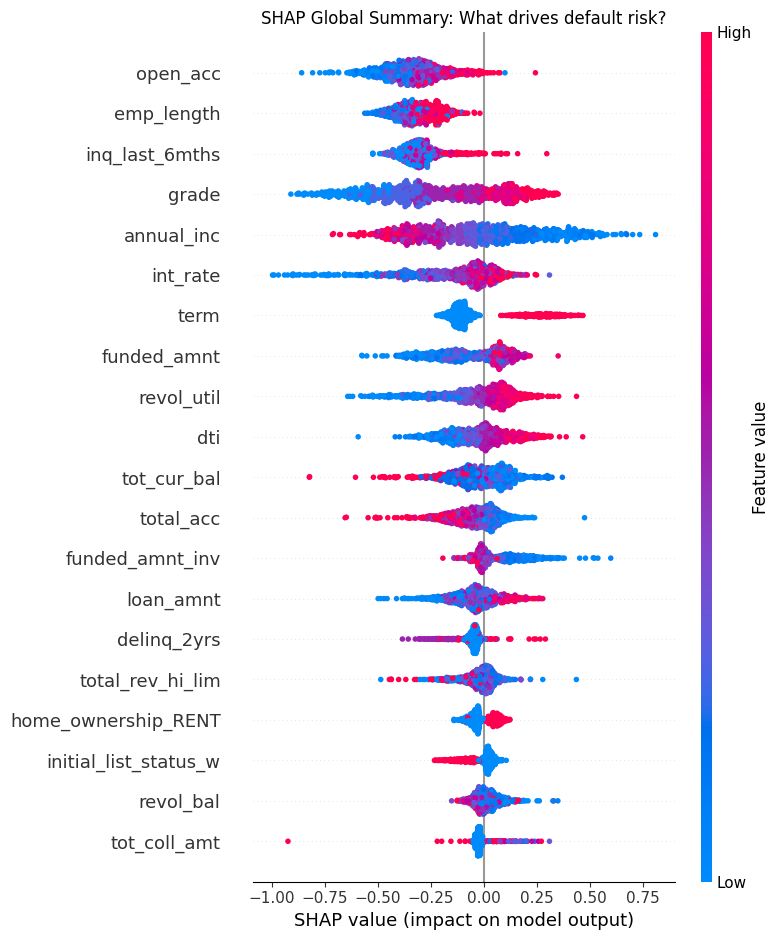


Generating SHAP Waterfall Plot for Applicant #0...


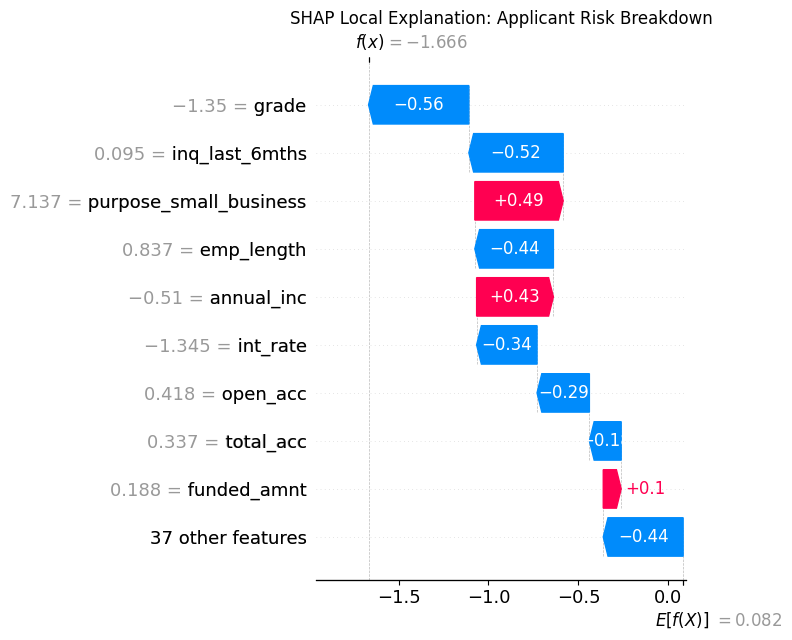

In [103]:
print("--- Running SHAP for XGBoost Model ---")

# 1. Initialize the SHAP Explainer using your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# PRO-TIP: SHAP takes a long time to run on 50,000 rows. 
# We will take a random sample of 1,000 test rows to generate the plots quickly!
X_test_sample = X_test_scaled.sample(n=1000, random_state=42)

# Calculate SHAP values for the sample
shap_values = explainer.shap_values(X_test_sample)

# ==========================================
# CHART 1: GLOBAL TRANSPARENCY (The Bank's Policy)
# ==========================================
print("\nGenerating SHAP Summary Plot...")
# This plot shows HOW features impact the model. 
# Red dots = High value of the feature. Blue dots = Low value.
# Right side = Pushes risk higher. Left side = Pushes risk lower.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Global Summary: What drives default risk?")
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: LOCAL TRANSPARENCY (Explaining a Single Applicant)
# ==========================================
print("\nGenerating SHAP Waterfall Plot for Applicant #0...")
# Let's look at the very first applicant in our sample to see WHY they got their specific score.
# This proves to regulators that you can explain individual automated decisions.

# Create an Explanation object for the single applicant
explanation = shap.Explanation(values=shap_values[0], 
                               base_values=explainer.expected_value, 
                               data=X_test_sample.iloc[0], 
                               feature_names=X_test_sample.columns)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Local Explanation: Applicant Risk Breakdown")
plt.tight_layout()
plt.show()

In [104]:
# ==========================================
# Training Model 3b: XGBoost (After modifying the custom decision threshold of 30%)
# ==========================================

print("--- Training TUNED Model #3b: XGBoost (After modifying the custom decision threshold of 30%)---")

# Calculate the ratio of Good Loans to Bad Loans in your training data
# This tells XGBoost exactly how heavily to penalize missing a Bad Loan
ratio = float(np.sum(y_train_balanced == 0)) / np.sum(y_train_balanced == 1)

# 1. Initialize the Tuned Model
xgb_tuned = XGBClassifier(
    random_state=42, 
    n_jobs=-1,
    scale_pos_weight=ratio,  # The Banker's Penalty
    max_depth=4,             # Prevents overfitting (Boosts AUC)
    learning_rate=0.1,       # Learns slower and smarter (Boosts AUC)
    n_estimators=200         # Builds more trees to compensate for slow learning
)

# 2. Train the model
xgb_tuned.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions (Probabilities first)
y_pred_proba_xgb = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

# 4. CUSTOM DECISION THRESHOLD (The Secret Weapon)
# Instead of 50%, we flag them as 'Bad' (1) if risk is >= 30%
custom_threshold = 0.30
y_pred_custom = (y_pred_proba_xgb >= custom_threshold).astype(int)

print("\n--- TUNED XGBOOST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_custom):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_custom):.4f} <- Watch this go UP!")
print(f"F1-Score:  {f1_score(y_test, y_pred_custom):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f} <- Watch this go UP!")

print("\n--- NEW CONFUSION MATRIX ---")
cm_tuned = confusion_matrix(y_test, y_pred_custom)
print(f"True Negatives  (Predicted Good, Actually Good): {cm_tuned[0][0]}")
print(f"False Positives (Predicted Bad,  Actually Good): {cm_tuned[0][1]} <- 'Lost Business'")
print(f"False Negatives (Predicted Good, Actually Bad):  {cm_tuned[1][0]} <- 'Financial Loss' (Should be lower!)")
print(f"True Positives  (Predicted Bad,  Actually Bad):  {cm_tuned[1][1]}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_custom))

# THE BLACK BOX: Built-in Feature Importance

print("\n--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---")
xgb_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': xgb_tuned.feature_importances_
})

# Sort by most important
xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)
print(xgb_importance.head(10))

--- Training TUNED Model #3b: XGBoost (After modifying the custom decision threshold of 30%)---

--- TUNED XGBOOST PERFORMANCE METRICS ---
Accuracy:  0.7126
Precision: 0.3238
Recall:    0.5178 <- Watch this go UP!
F1-Score:  0.3984
ROC-AUC:   0.7006 <- Watch this go UP!

--- NEW CONFUSION MATRIX ---
True Negatives  (Predicted Good, Actually Good): 31728
False Positives (Predicted Bad,  Actually Good): 10214 <- 'Lost Business'
False Negatives (Predicted Good, Actually Bad):  4555 <- 'Financial Loss' (Should be lower!)
True Positives  (Predicted Bad,  Actually Bad):  4891

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81     41942
           1       0.32      0.52      0.40      9446

    accuracy                           0.71     51388
   macro avg       0.60      0.64      0.60     51388
weighted avg       0.77      0.71      0.74     51388


--- BUILT-IN FEATURE IMPORTANCE (The Problem) ---
     

--- Running SHAP for the TUNED XGBoost Model ---

Generating Global Summary Plot...


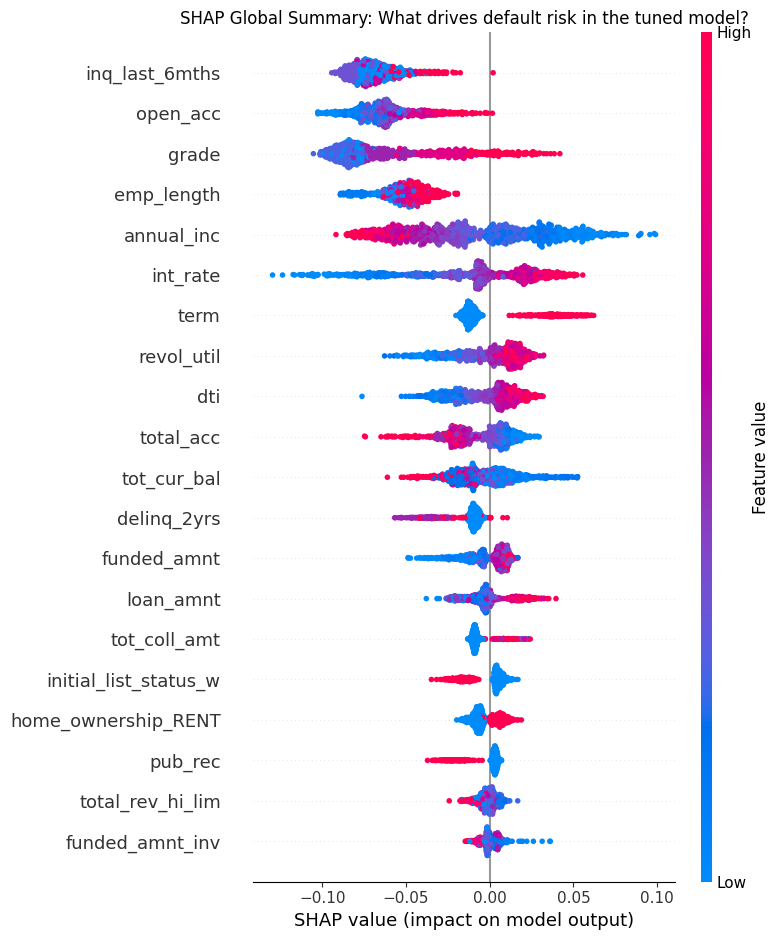


Generating Local Waterfall Plot for Applicant #0...


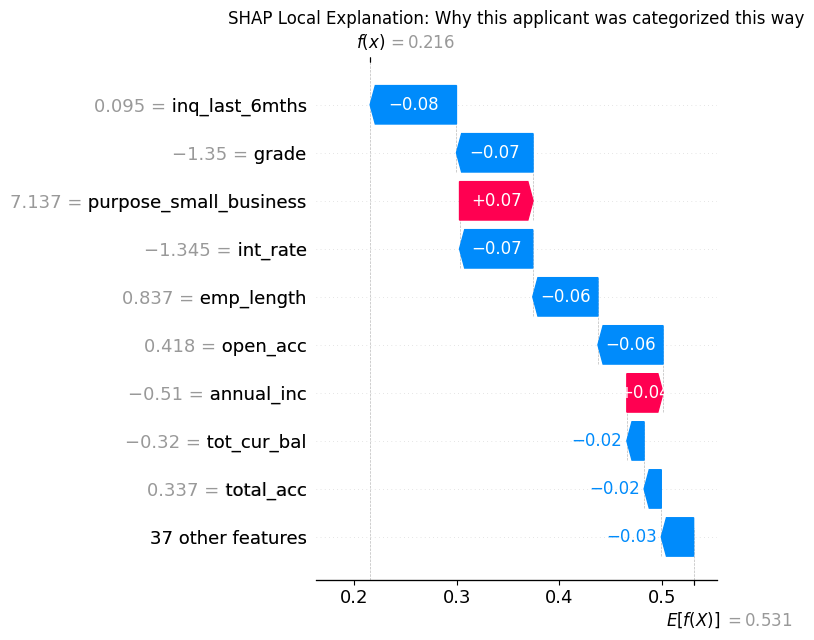

In [105]:
print("--- Running SHAP for the TUNED XGBoost Model ---")

# 1. Initialize the SHAP Explainer
# We specify model_output='probability' so SHAP explains the 0-100% risk score 
explainer = shap.TreeExplainer(xgb_tuned, data=X_train_balanced, model_output='probability', feature_perturbation='interventional')

# 2. Calculate SHAP values for a sample
# Taking a random sample of 1,000 for faster performance
X_test_sample = X_test_scaled.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# ==========================================
# CHART 1: GLOBAL SUMMARY PLOT
# ==========================================
print("\nGenerating Global Summary Plot...")
# This visualizes the 'Banker's Policy' across all customers
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Global Summary: What drives default risk in the tuned model?")
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: LOCAL WATERFALL PLOT
# ==========================================
print("\nGenerating Local Waterfall Plot for Applicant #0...")
# This explains exactly why Applicant #0 was approved or rejected
# We calculate the SHAP base value specifically for the probability output
expected_value = explainer.expected_value 

# Create the Explanation object
explanation = shap.Explanation(values=shap_values[0], 
                               base_values=expected_value, 
                               data=X_test_sample.iloc[0], 
                               feature_names=X_test_sample.columns)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Local Explanation: Why this applicant was categorized this way")
plt.tight_layout()
plt.show()